# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4366s 26us/step
Train shape: (50000, 32, 32, 3) (50000, 1)
Test shape: (10000, 32, 32, 3) (10000, 1)


## 🖼️ Visualize Sample Images

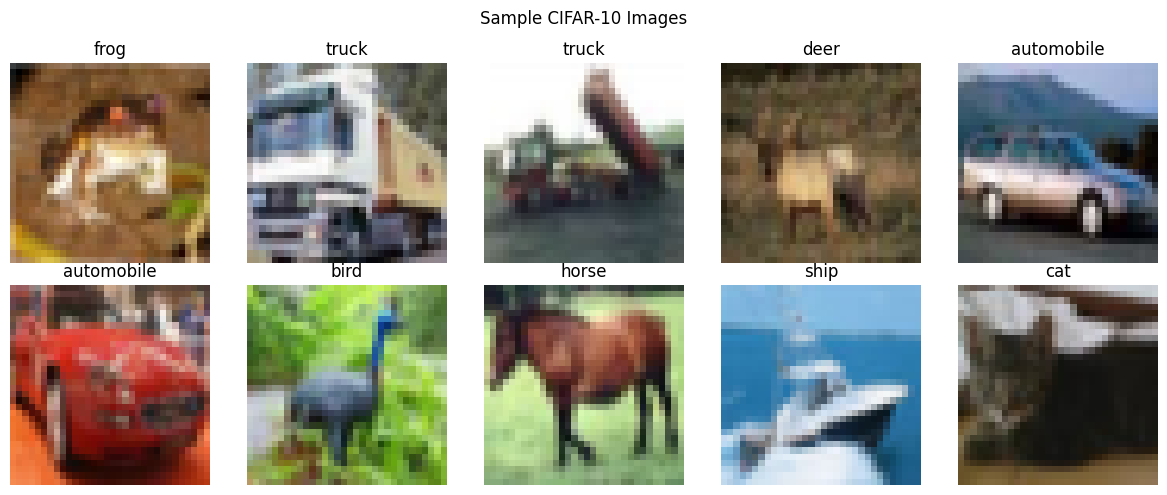

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i][0]])
    ax.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [4]:

x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print("Normalized train range:", x_train_norm.min(), "-", x_train_norm.max())
print("y_train_cat shape:", y_train_cat.shape)

Normalized train range: 0.0 - 1.0
y_train_cat shape: (50000, 10)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [5]:
def build_ann():
    model = keras.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)),
        layers.Dense(1024, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name="ANN")
    return model

ann_model = build_ann()
ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
ann_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

start = time.time()
ann_history = ann_model.fit(
    x_train_norm, y_train_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1
)
ann_train_time = time.time() - start
print(f"ANN training time: {ann_train_time:.1f}s")

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 50ms/step - accuracy: 0.2596 - loss: 2.0171 - val_accuracy: 0.3342 - val_loss: 1.8493
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.3211 - loss: 1.8592 - val_accuracy: 0.3732 - val_loss: 1.7706
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.3456 - loss: 1.8006 - val_accuracy: 0.3926 - val_loss: 1.7269
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.3590 - loss: 1.7727 - val_accuracy: 0.3936 - val_loss: 1.7232
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.3637 - loss: 1.7550 - val_accuracy: 0.4018 - val_loss: 1.6965
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.3773 - loss: 1.7221 - val_accuracy: 0.4136 - val_loss: 1.6734
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.3830 - loss: 1.7019 - val_accuracy: 0.4144 - val_loss: 1.6632
Epoch 8/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - accuracy: 0.3875 - loss: 1.6890 - 

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"ANN Test Accuracy: {ann_test_acc:.4f}")
print(f"ANN Test Loss: {ann_test_loss:.4f}")

ANN Test Accuracy: 0.4679
ANN Test Loss: 1.5209


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [8]:
def build_cnn():
    model = keras.Sequential([
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ], name="CNN")
    return model

cnn_model = build_cnn()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
cnn_model.compile(optimizer='adam',
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

start = time.time()
cnn_history = cnn_model.fit(
    x_train_norm, y_train_cat,
    validation_split=0.1,
    epochs=2,
    batch_size=128,
    verbose=1
)
cnn_train_time = time.time() - start
print(f"CNN training time: {cnn_train_time:.1f}s")

Epoch 1/2
352/352 ━━━━━━━━━━━━━━━━━━━━ 170s 473ms/step - accuracy: 0.6794 - loss: 0.9183 - val_accuracy: 0.6794 - val_loss: 1.0491
Epoch 2/2
352/352 ━━━━━━━━━━━━━━━━━━━━ 205s 483ms/step - accuracy: 0.7072 - loss: 0.8376 - val_accuracy: 0.7228 - val_loss: 0.8514
CNN training time: 376.6s


In [12]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"CNN Test Accuracy: {cnn_test_acc:.4f}")
print(f"CNN Test Loss: {cnn_test_loss:.4f}")

CNN Test Accuracy: 0.7017
CNN Test Loss: 0.9114


## 📈 Compare Learning Curves

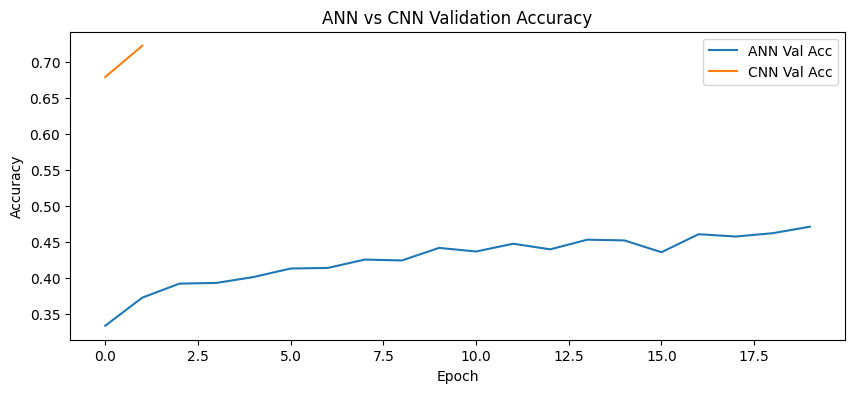

In [13]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [15]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomZoom(0.1),
])

def build_cnn_augmented():
    inputs = keras.Input(shape=(32,32,3))
    x = data_augmentation(inputs)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="CNN_Augmented")

cnn_aug_model = build_cnn_augmented()
cnn_aug_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

start = time.time()
cnn_aug_history = cnn_aug_model.fit(
    x_train_norm, y_train_cat,
    validation_split=0.1,
    epochs=2,
    batch_size=128,
    verbose=1
)
cnn_aug_train_time = time.time() - start
print(f"CNN+Augmentation training time: {cnn_aug_train_time:.1f}s")

Epoch 1/2
352/352 ━━━━━━━━━━━━━━━━━━━━ 184s 513ms/step - accuracy: 0.3305 - loss: 1.8436 - val_accuracy: 0.2180 - val_loss: 3.1824
Epoch 2/2
352/352 ━━━━━━━━━━━━━━━━━━━━ 198s 502ms/step - accuracy: 0.4393 - loss: 1.5393 - val_accuracy: 0.5110 - val_loss: 1.3677
CNN+Augmentation training time: 408.9s


In [16]:
cnn_aug_test_loss, cnn_aug_test_acc = cnn_aug_model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"CNN+Augmentation Test Accuracy: {cnn_aug_test_acc:.4f}")
print(f"CNN+Augmentation Test Loss: {cnn_aug_test_loss:.4f}")

CNN+Augmentation Test Accuracy: 0.5052
CNN+Augmentation Test Loss: 1.3956


In [17]:
cnn_sgd_model = build_cnn()
cnn_sgd_model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start = time.time()
cnn_sgd_history = cnn_sgd_model.fit(
    x_train_norm, y_train_cat,
    validation_split=0.1,
    epochs=2,
    batch_size=128,
    verbose=1
)
cnn_sgd_train_time = time.time() - start

cnn_sgd_test_loss, cnn_sgd_test_acc = cnn_sgd_model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"CNN+SGD Test Accuracy: {cnn_sgd_test_acc:.4f}")
print(f"CNN+SGD Test Loss: {cnn_sgd_test_loss:.4f}")


Epoch 1/2
352/352 ━━━━━━━━━━━━━━━━━━━━ 174s 489ms/step - accuracy: 0.3792 - loss: 1.7277 - val_accuracy: 0.2866 - val_loss: 2.2664
Epoch 2/2
352/352 ━━━━━━━━━━━━━━━━━━━━ 201s 487ms/step - accuracy: 0.4909 - loss: 1.3995 - val_accuracy: 0.5690 - val_loss: 1.2424
CNN+SGD Test Accuracy: 0.5526
CNN+SGD Test Loss: 1.2590


# 📊 Final Comparison Table

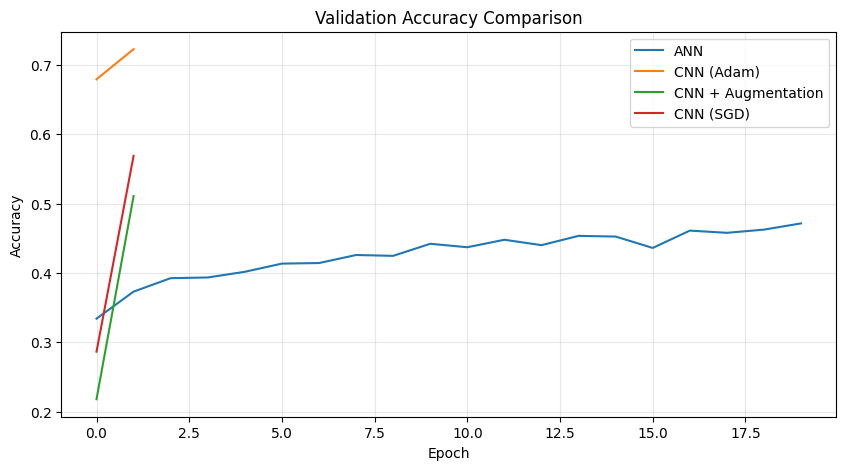

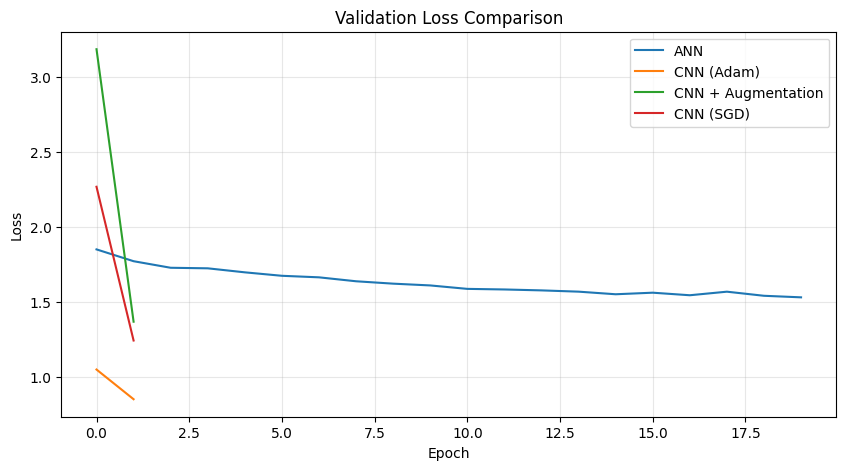

In [18]:
def plot_history(histories, labels, metric='accuracy'):
    plt.figure(figsize=(10,5))
    for h, label in zip(histories, labels):
        plt.plot(h.history[f'val_{metric}'], label=label)
    plt.title(f'Validation {metric.capitalize()} Comparison')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_history(
    [ann_history, cnn_history, cnn_aug_history, cnn_sgd_history],
    ['ANN', 'CNN (Adam)', 'CNN + Augmentation', 'CNN (SGD)'],
    metric='accuracy'
)
plot_history(
    [ann_history, cnn_history, cnn_aug_history, cnn_sgd_history],
    ['ANN', 'CNN (Adam)', 'CNN + Augmentation', 'CNN (SGD)'],
    metric='loss'
)


In [19]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['ANN', 'CNN (Adam)', 'CNN + Augmentation', 'CNN (SGD)'],
    'Test Accuracy': [ann_test_acc, cnn_test_acc, cnn_aug_test_acc, cnn_sgd_test_acc],
    'Test Loss': [ann_test_loss, cnn_test_loss, cnn_aug_test_loss, cnn_sgd_test_loss],
    'Train Time (s)': [ann_train_time, cnn_train_time, cnn_aug_train_time, cnn_sgd_train_time],
    'Params': [ann_model.count_params(), cnn_model.count_params(),
               cnn_aug_model.count_params(), cnn_sgd_model.count_params()]
})
results


,Model,Test Accuracy,Test Loss,Train Time (s),Params
0,ANN,0.4679,1.520901,361.574361,3805450
1,CNN (Adam),0.7017,0.911381,376.629923,667434
2,CNN + Augmentation,0.5052,1.395570,408.923295,667434
3,CNN (SGD),0.5526,1.259040,406.161719,667434


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step


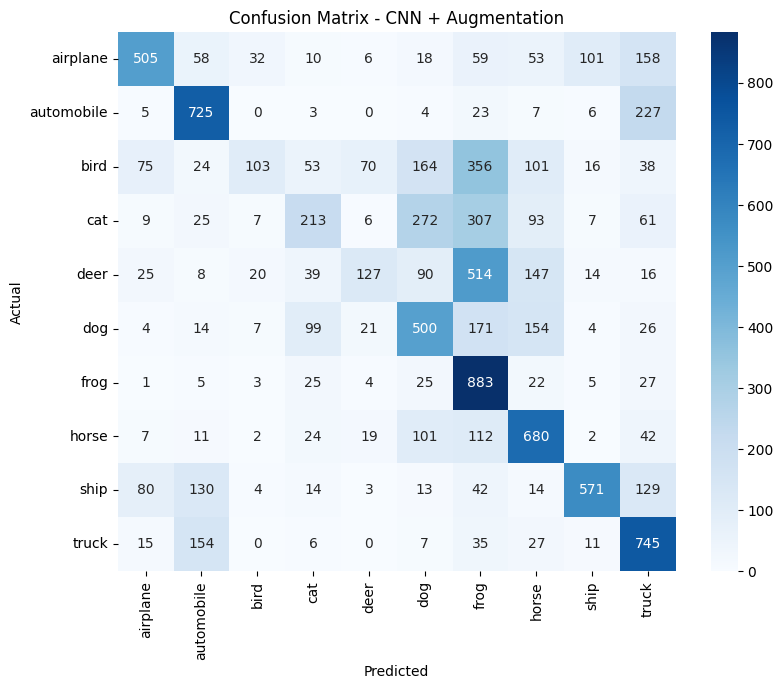

              precision    recall  f1-score   support

    airplane       0.70      0.51      0.59      1000
  automobile       0.63      0.72      0.67      1000
        bird       0.58      0.10      0.17      1000
         cat       0.44      0.21      0.29      1000
        deer       0.50      0.13      0.20      1000
         dog       0.42      0.50      0.46      1000
        frog       0.35      0.88      0.50      1000
       horse       0.52      0.68      0.59      1000
        ship       0.77      0.57      0.66      1000
       truck       0.51      0.74      0.60      1000

    accuracy                           0.51     10000
   macro avg       0.54      0.51      0.47     10000
weighted avg       0.54      0.51      0.47     10000



In [20]:

y_pred = cnn_aug_model.predict(x_test_norm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - CNN + Augmentation')
plt.show()

print(classification_report(y_true, y_pred_classes, target_names=class_names))


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**